<a href="https://colab.research.google.com/github/khaliqtaimoor6-codes/Cats-vs-Dogs-Classifier/blob/main/Cats_vs_Dogs_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup Kaggle API with `kaggle.json`

Since you've already uploaded your `kaggle.json` file, we just need to move it to the correct location and set the appropriate permissions for the Kaggle API to use it.

In [18]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json file to the .kaggle directory
!mv /content/kaggle.json ~/.kaggle/

# Set permissions for kaggle.json to make it readable only by the owner
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured using the uploaded kaggle.json.")

mv: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured using the uploaded kaggle.json.


Now that the Kaggle API is configured, we can download the 'Dogs vs. Cats' dataset.

In [19]:
# Download the 'Dogs vs. Cats' dataset.
# Using the dataset ID provided by the user.
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

print("Dataset download initiated.")

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
dog-and-cat-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset download initiated.


In [20]:
# Unzip the downloaded dataset
# The zip file name is usually the dataset ID. Corrected to use the downloaded filename.
# We will extract it into a directory named 'dogs_vs_cats_data'.
!unzip -q dog-and-cat-classification-dataset.zip -d ./dogs_vs_cats_data/

print("Dataset unzipped into ./dogs_vs_cats_data/")

# List the contents to verify
!ls -R ./dogs_vs_cats_data/

replace ./dogs_vs_cats_data/PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Dataset unzipped into ./dogs_vs_cats_data/
./dogs_vs_cats_data/:
PetImages

./dogs_vs_cats_data/PetImages:
Cat  Dog

./dogs_vs_cats_data/PetImages/Cat:
0.jpg	   11608.jpg  1966.jpg	3573.jpg  5180.jpg  678.jpg   8397.jpg
10000.jpg  11609.jpg  1967.jpg	3574.jpg  5181.jpg  6790.jpg  8398.jpg
10001.jpg  1160.jpg   1968.jpg	3575.jpg  5182.jpg  6791.jpg  8399.jpg
10002.jpg  11610.jpg  1969.jpg	3576.jpg  5183.jpg  6792.jpg  839.jpg
10003.jpg  11611.jpg  196.jpg	3577.jpg  5184.jpg  6793.jpg  83.jpg
10004.jpg  11612.jpg  1970.jpg	3578.jpg  5185.jpg  6794.jpg  8400.jpg
10005.jpg  11613.jpg  1971.jpg	3579.jpg  5186.jpg  6795.jpg  8401.jpg
10006.jpg  11614.jpg  1972.jpg	357.jpg   5187.jpg  6796.jpg  8402.jpg
10007.jpg  11615.jpg  1973.jpg	3580.jpg  5188.jpg  6797.jpg  8403.jpg
10008.jpg  11616.jpg  1974.jpg	3581.jpg  5189.jpg  6798.jpg  8404.jpg
10009.jpg  11617.jpg  1975.jpg	3582.jpg  518.jpg   6799.jpg  8405

In [21]:
import os
from PIL import Image

bad_files = []
for cls in ['Cat', 'Dog']:
    folder = f'./dogs_vs_cats_data/PetImages/{cls}'
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            bad_files.append(fpath)

print(f"Found {len(bad_files)} corrupted files")
# then os.remove() them

Found 0 corrupted files


Instead of physically copying thousands of files into new folders (slow, wastes disk space), we'll build a custom PyTorch Dataset that just takes a list of file paths + labels and loads images on the fly. This is the standard, memory-efficient approach.

In [22]:
import os

data_dir = './dogs_vs_cats_data/PetImages'
classes = ['Cat', 'Dog']  # label 0 = Cat, label 1 = Dog

all_paths = []
all_labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    for fname in os.listdir(folder):
        all_paths.append(os.path.join(folder, fname))
        all_labels.append(label)

print(f"Total images: {len(all_paths)}")
print(f"Cats: {all_labels.count(0)}, Dogs: {all_labels.count(1)}")

Total images: 24998
Cats: 12499, Dogs: 12499


In [23]:
from sklearn.model_selection import train_test_split

# X = paths (not actual images yet), y = labels
X = all_paths
y = all_labels

# Split 1: 70% train, 30% leftover
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split 2: cut the 30% leftover into val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Train: 17498
Val:   3750
Test:  3750


In [24]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class CatsDogsDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

1
<class 'PIL.Image.Image'>


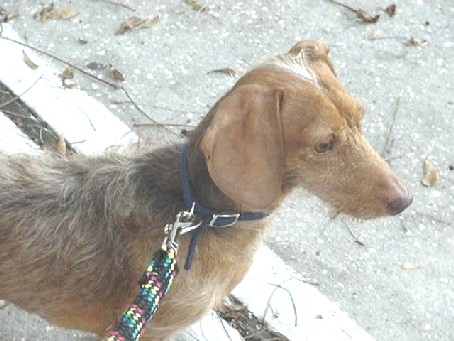

In [25]:
train_dataset = CatsDogsDataset(X_train, y_train)

# test it manually
image, label = train_dataset[0]
print(label)      # 0 or 1
print(type(image)) # PIL Image object for now (no transform yet)
image              # if in Jupyter, this will just show the picture

In [26]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [27]:
train_dataset = CatsDogsDataset(X_train, y_train, transform=train_transform)
val_dataset   = CatsDogsDataset(X_val, y_val, transform=eval_transform)
test_dataset  = CatsDogsDataset(X_test, y_test, transform=eval_transform)

In [28]:
image, label = train_dataset[0]
print(type(image))   # should now say <class 'torch.Tensor'>
print(image.shape)   # should be torch.Size([3, 128, 128])

<class 'torch.Tensor'>
torch.Size([3, 128, 128])


In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
images, labels = next(iter(train_loader))

print(images.shape)  # torch.Size([32, 3, 128, 128])
print(labels.shape)  # torch.Size([32])
print(labels)         # e.g. tensor([1, 0, 0, 1, 1, ...]) - 32 labels

torch.Size([32, 3, 128, 128])
torch.Size([32])
tensor([0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
        0, 0, 1, 1, 0, 1, 0, 1])


In [31]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor
        self.conv_layers = nn.Sequential(#in channel = 3 channels , out channels= 16 filters
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128x128 -> 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64x64 -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16
        )

        # Classifier head
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)   # single output -> cat vs dog
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [32]:
model = SimpleCNN()
images, labels = next(iter(train_loader))
output = model(images)
print(output.shape)   # should be torch.Size([32, 1])

torch.Size([32, 1])


In [33]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
num_epochs = 7

# Initialize lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()   # tell the model we're in training mode (activates dropout)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)  # shape [32] -> [32, 1]

        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 2. Backward pass + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track stats
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---------- VALIDATION ----------
    model.eval()   # switch to evaluation mode (turns off dropout)
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():   # no need to track gradients here
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} - Val Acc:   {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/7
  Train Loss: 0.3575 - Train Acc: 0.8471
  Val Loss:   0.3540 - Val Acc:   0.8408
Epoch 2/7
  Train Loss: 0.3349 - Train Acc: 0.8555
  Val Loss:   0.3286 - Val Acc:   0.8595
Epoch 3/7
  Train Loss: 0.3144 - Train Acc: 0.8689
  Val Loss:   0.3378 - Val Acc:   0.8467
Epoch 4/7
  Train Loss: 0.2987 - Train Acc: 0.8726
  Val Loss:   0.3362 - Val Acc:   0.8555
Epoch 5/7
  Train Loss: 0.2870 - Train Acc: 0.8815
  Val Loss:   0.3020 - Val Acc:   0.8643
Epoch 6/7
  Train Loss: 0.2704 - Train Acc: 0.8883
  Val Loss:   0.3248 - Val Acc:   0.8576
Epoch 7/7
  Train Loss: 0.2670 - Train Acc: 0.8900
  Val Loss:   0.2847 - Val Acc:   0.8803


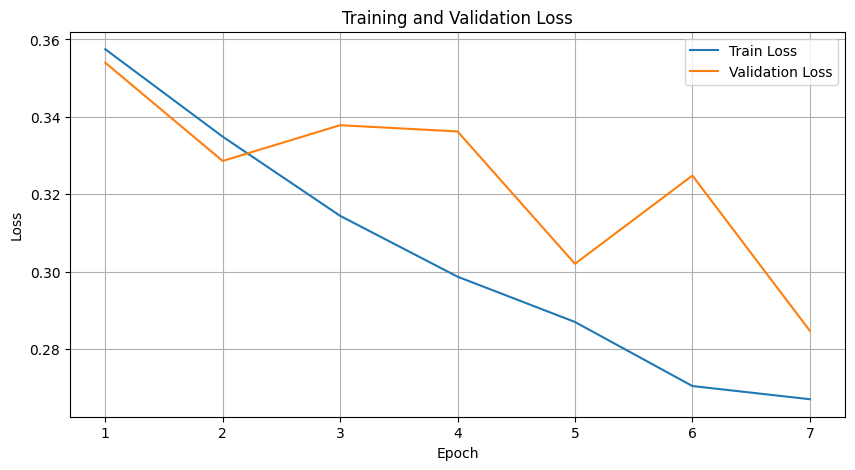

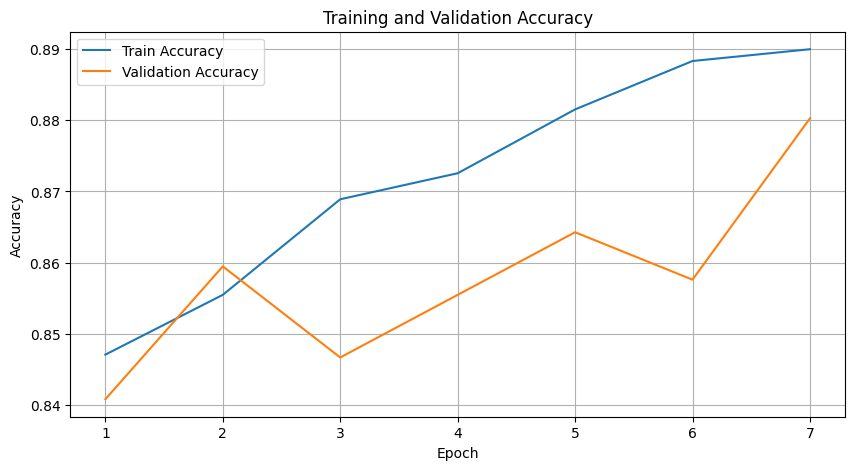

In [36]:
import matplotlib.pyplot as plt

# Plotting Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()